# Pontryagin's Maximum Principle
## Optimal Control with Constrained Controls via the Hamiltonian Framework

This notebook develops **Pontryagin's Maximum Principle (PMP)** from first principles and applies it to solve optimal control problems where the control input is constrained. PMP extends the calculus of variations to handle inequality constraints on controls — a situation that arises throughout engineering, economics, and physics.

**What you'll learn:**
1. The optimal control problem formulation and its relationship to calculus of variations
2. The Hamiltonian, costate equations, and the maximum principle
3. Bang-bang control and switching functions
4. Minimum-energy and time-optimal control via shooting methods
5. Singular arcs and the generalized Legendre-Clebsch condition

**Prerequisites:** Calculus of variations (Euler-Lagrange equation, first-order necessary conditions), ordinary differential equations, basic numerical methods.

**References:**
- Kirk, *Optimal Control Theory: An Introduction*, Dover, 2004.
- Liberzon, *Calculus of Variations and Optimal Control Theory*, Princeton, 2012.
- Bryson & Ho, *Applied Optimal Control*, Taylor & Francis, 1975.

---
## 1. Introduction: Optimal Control Beyond Calculus of Variations

In the calculus of variations, we seek functions that extremize functionals — but the "control" (the function we optimize over) is **unconstrained**. In practice, actuators have limits: a rocket engine has maximum thrust, a motor has maximum torque, a rudder has maximum deflection angle.

**Pontryagin's Maximum Principle** (1956) provides first-order necessary conditions for optimality when the control $u(t)$ is constrained to lie in a set $\mathcal{U}$. It is one of the most powerful results in optimal control theory.

| Aspect | Calculus of Variations | Pontryagin's Maximum Principle |
|--------|----------------------|-------------------------------|
| **Control constraints** | None ($u \in \mathbb{R}^m$) | $u \in \mathcal{U}$ (bounded set) |
| **Necessary condition** | Euler-Lagrange equation | Hamiltonian minimization |
| **Key tool** | Variation $\delta y$ | Needle variation |
| **Regularity** | Smooth extremals | Possibly discontinuous controls |
| **Result type** | Differential equation | Pointwise optimization + ODE system |

---
## 2. The Optimal Control Problem

We consider a dynamical system with **state** $x(t) \in \mathbb{R}^n$ and **control** $u(t) \in \mathcal{U} \subseteq \mathbb{R}^m$:

$$\dot{x}(t) = f(x(t), u(t), t), \quad x(t_0) = x_0$$

We wish to choose the control $u(\cdot)$ to minimize the **Bolza cost functional**:

$$\boxed{J[u] = \phi(x(T), T) + \int_{t_0}^{T} L(x(t), u(t), t) \, dt}$$

where:
- $\phi(x(T), T)$: **terminal cost** (Mayer term) — penalizes the final state
- $L(x, u, t)$: **running cost** (Lagrange term) — penalizes the trajectory and control effort
- $\mathcal{U}$: **admissible control set** — the constraint on $u$

**Special cases:**
- **Mayer problem:** $L \equiv 0$ (only terminal cost)
- **Lagrange problem:** $\phi \equiv 0$ (only running cost)
- **Minimum-time problem:** $L \equiv 1$, $\phi \equiv 0$ (minimize $T - t_0$)

The constraint $u(t) \in \mathcal{U}$ is what distinguishes this from a standard calculus of variations problem. The Euler-Lagrange equation assumes $u$ is an interior point, but when $u$ hits the boundary of $\mathcal{U}$, we need PMP.

---
## 3. The Hamiltonian and Costate Equations

### The Control Hamiltonian

Define the **Hamiltonian** (or Pontryagin Hamiltonian):

$$\boxed{H(x, \lambda, u, t) = L(x, u, t) + \lambda^T f(x, u, t)}$$

where $\lambda(t) \in \mathbb{R}^n$ is the **costate** (or adjoint) vector — the continuous-time analogue of Lagrange multipliers.

### Derivation via Needle Variations

The key insight of PMP is the **needle variation**: instead of smooth perturbations $\varepsilon \eta(t)$ (as in calculus of variations), we perturb the control on a tiny interval $[\tau, \tau + \varepsilon]$:

$$u^\varepsilon(t) = \begin{cases} v & \text{if } t \in [\tau, \tau + \varepsilon] \\ u^*(t) & \text{otherwise} \end{cases}$$

where $v \in \mathcal{U}$ is any admissible control value. This perturbation is valid even when $\mathcal{U}$ is a bounded set — unlike smooth variations that might leave $\mathcal{U}$.

Analyzing the effect of this needle variation on the cost $J$ and requiring $\delta J \geq 0$ (for minimization) leads to:

### Costate (Adjoint) Equations

$$\boxed{\dot{\lambda}(t) = -\frac{\partial H}{\partial x}(x^*, \lambda, u^*, t)}$$

This is a **backward ODE** — it runs from $T$ back to $t_0$, with terminal condition determined by the transversality conditions.

### Optimality Condition

If $u^*$ is in the **interior** of $\mathcal{U}$, the standard first-order condition applies:

$$\frac{\partial H}{\partial u}(x^*, \lambda, u^*, t) = 0$$

But if $u^*$ is on the **boundary** of $\mathcal{U}$, this gradient condition is replaced by the maximum principle (see next section).

---
## 4. Statement of Pontryagin's Maximum Principle

**Theorem (Pontryagin's Maximum Principle).** Let $u^*(t)$ be an optimal control and $x^*(t)$ the corresponding optimal trajectory. Then there exists a costate function $\lambda(t)$ such that:

**1. State equation (forward):**
$$\dot{x}^*(t) = \frac{\partial H}{\partial \lambda}(x^*, \lambda, u^*, t) = f(x^*, u^*, t)$$

**2. Costate equation (backward):**
$$\dot{\lambda}(t) = -\frac{\partial H}{\partial x}(x^*, \lambda, u^*, t)$$

**3. Hamiltonian minimization (pointwise):**
$$\boxed{u^*(t) = \arg\min_{u \in \mathcal{U}} H(x^*(t), \lambda(t), u, t)}$$

**4. Transversality conditions:**
- Fixed final state $x(T) = x_T$: $\lambda(T)$ is free
- Free final state: $\lambda(T) = \frac{\partial \phi}{\partial x}(x^*(T), T)$
- Free final time: $H(x^*(T), \lambda(T), u^*(T), T) = -\frac{\partial \phi}{\partial T}(x^*(T), T)$
  - If $H$ and $\phi$ do not depend explicitly on $t$: $H \equiv 0$ along the optimal trajectory

**5. Hamiltonian constancy:**
If $H$ does not depend explicitly on $t$, then $H$ is constant along the optimal trajectory:
$$\frac{dH}{dt} = \frac{\partial H}{\partial t} = 0 \quad \Longrightarrow \quad H(x^*(t), \lambda(t), u^*(t)) = \text{const}$$

> **Note:** We use the convention where PMP *minimizes* $H$. Some references (notably the original Soviet literature) use $\max H$ with a sign change in the Hamiltonian definition.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, solve_bvp
from scipy.optimize import brentq, fsolve

%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})

np.random.seed(42)

In [2]:
# =============================================================================
# Global Constants
# =============================================================================

# Minimum-energy transfer (Section 6)
X0_ENERGY = np.array([0.0, 0.0])      # initial state [position, velocity]
XF_ENERGY = np.array([1.0, 0.0])      # final state [position, velocity]
T_FINAL_ENERGY = 2.0                  # fixed final time
N_GRID = 200                          # number of time grid points

# Bang-bang / time-optimal control (Sections 5, 7)
U_MAX = 1.0                           # maximum control magnitude
X0_BANG = np.array([0.0, 0.0])        # initial state
XF_BANG = np.array([1.0, 0.0])        # final state

# Singular arc (Section 8)
DRAG_COEFF = 0.1                      # linear drag coefficient
MASS = 1.0                            # rocket mass (constant for simplicity)

# Numerical tolerances
SHOOTING_TOL = 1e-10                  # shooting method convergence tolerance
RK4_DT = 1e-3                         # RK4 time step for verification
FD_EPSILON = 1e-7                     # finite difference step
HAMILTONIAN_TOL = 1e-8                # tolerance for H constancy check

---
## 5. Bang-Bang Control

### Linear-in-$u$ Hamiltonian

When the Hamiltonian is **linear in $u$**, the minimization $\min_{u \in [u_{\min}, u_{\max}]} H$ has a particularly simple solution. Write:

$$H = H_0(x, \lambda, t) + \sigma(t) \cdot u$$

where $\sigma(t) = \frac{\partial H}{\partial u}$ is the **switching function**. Then:

$$\boxed{u^*(t) = \begin{cases} u_{\min} & \text{if } \sigma(t) > 0 \\ u_{\max} & \text{if } \sigma(t) < 0 \end{cases}}$$

The optimal control **switches** between its extreme values — this is called **bang-bang control**.

### Time-Optimal Double Integrator

Consider the double integrator $\ddot{x} = u$ with $|u| \leq 1$. In state-space form:

$$\dot{x}_1 = x_2, \quad \dot{x}_2 = u, \quad |u| \leq 1$$

For the time-optimal problem ($L = 1$, minimize $T$), the Hamiltonian is:

$$H = 1 + \lambda_1 x_2 + \lambda_2 u$$

The switching function is $\sigma(t) = \lambda_2(t)$. The costate equations are:

$$\dot{\lambda}_1 = 0, \quad \dot{\lambda}_2 = -\lambda_1$$

So $\lambda_1 = c_1$ (constant) and $\lambda_2(t) = -c_1 t + c_2$ — a **linear function of time**. This means:
- $\sigma(t)$ has **at most one zero** (one switch)
- The optimal control is bang-bang with **at most one switch**

In [3]:
def hamiltonian(x, lam, u, t, problem='energy'):
    """Compute the Hamiltonian for the double integrator.

    For the double integrator x1_dot = x2, x2_dot = u:
      - 'energy': H = 0.5*u^2 + lam1*x2 + lam2*u  (minimum energy)
      - 'time':   H = 1 + lam1*x2 + lam2*u         (minimum time)

    Args:
        x: State vector [x1, x2]. Shape: (2,).
        lam: Costate vector [lam1, lam2]. Shape: (2,).
        u: Control input. Scalar.
        t: Time. Scalar.
        problem: Problem type, 'energy' or 'time'. String.

    Returns:
        Hamiltonian value. Scalar.
    """
    if problem == 'energy':
        L = 0.5 * u**2
    elif problem == 'time':
        L = 1.0
    else:
        raise ValueError(f"Unknown problem type: {problem}")

    # f = [x2, u]
    H = L + lam[0] * x[1] + lam[1] * u
    return H


def costate_ode(t, state_costate, problem='energy'):
    """Right-hand side for the combined state + costate ODE system.

    State:   x1_dot = x2,  x2_dot = u
    Costate: lam1_dot = -dH/dx1 = 0,  lam2_dot = -dH/dx2 = -lam1

    The optimal control is determined by the problem type:
      - 'energy': u* = -lam2  (from dH/du = u + lam2 = 0)
      - 'time':   u* = -sign(lam2)  (bang-bang)

    Args:
        t: Time. Scalar.
        state_costate: Combined vector [x1, x2, lam1, lam2]. Shape: (4,).
        problem: Problem type, 'energy' or 'time'. String.

    Returns:
        Time derivatives [x1_dot, x2_dot, lam1_dot, lam2_dot]. Shape: (4,).
    """
    x1, x2, lam1, lam2 = state_costate

    # Optimal control
    if problem == 'energy':
        u = -lam2
    elif problem == 'time':
        u = -np.sign(lam2) * U_MAX
        if abs(lam2) < 1e-12:
            u = 0.0  # singular case
    else:
        raise ValueError(f"Unknown problem type: {problem}")

    x1_dot = x2
    x2_dot = u
    lam1_dot = 0.0        # -dH/dx1 = 0
    lam2_dot = -lam1      # -dH/dx2 = -lam1

    return [x1_dot, x2_dot, lam1_dot, lam2_dot]

In [4]:
def bang_bang_double_integrator(x0, xf, u_max=U_MAX):
    """Compute analytical bang-bang time-optimal control for the double integrator.

    For the system x1_dot = x2, x2_dot = u with |u| <= u_max,
    transfer from x0 to xf in minimum time.

    The optimal trajectories follow parabolas in the phase plane:
      u = +u_max: x1 = x1_0 + x2_0*t + 0.5*u_max*t^2
      u = -u_max: x1 = x1_0 + x2_0*t - 0.5*u_max*t^2

    The switching curve passes through the origin:
      x1 = -sign(x2) * x2^2 / (2*u_max)

    Args:
        x0: Initial state [x1_0, x2_0]. Shape: (2,).
        xf: Final state [x1_f, x2_f]. Shape: (2,).
        u_max: Maximum control magnitude. Scalar.

    Returns:
        t_switch: Time of control switch. Scalar.
        t_final: Total time to reach xf. Scalar.
        u_initial: Initial control value (+u_max or -u_max). Scalar.
    """
    x1_0, x2_0 = x0
    x1_f, x2_f = xf

    # Shift coordinates so xf is at origin
    dx1 = x1_f - x1_0
    dx2 = x2_f - x2_0

    # Try both initial control signs and pick the valid one
    solutions = []
    for u_init_sign in [1.0, -1.0]:
        u1 = u_init_sign * u_max   # initial control
        u2 = -u1                   # control after switch

        # Phase 1: x2(t1) = x2_0 + u1*t1
        # Phase 2: x2(t1+t2) = (x2_0 + u1*t1) + u2*t2 = x2_f
        # => u1*t1 + u2*t2 = dx2
        # Phase 1: x1(t1) = x1_0 + x2_0*t1 + 0.5*u1*t1^2
        # Phase 2: x1(t1+t2) = x1(t1) + (x2_0+u1*t1)*t2 + 0.5*u2*t2^2 = x1_f

        # From velocity: t2 = (dx2 - u1*t1) / u2
        # Substitute into position equation and solve for t1

        # Quadratic in t1:
        # 0.5*(u1 - u1^2/u2)*t1^2 + (x2_0 - x2_0*u1/u2 - dx2*u1/u2)*t1
        #   + (x2_0*dx2/u2 + 0.5*dx2^2/u2 - dx1) = 0
        # Since u2 = -u1: u1/u2 = -1, u1 - u1^2/u2 = u1 + u1 = 2*u1

        a_coeff = u1  # simplified: 0.5 * 2 * u1
        b_coeff = 2 * x2_0 + dx2  # simplified
        c_coeff = (x2_0 * dx2 - 0.5 * dx2**2) / u1 - dx1  # simplified

        discriminant = b_coeff**2 - 4 * a_coeff * c_coeff
        if discriminant < 0:
            continue

        for sign in [1, -1]:
            t1 = (-b_coeff + sign * np.sqrt(discriminant)) / (2 * a_coeff)
            t2 = (dx2 - u1 * t1) / u2
            if t1 >= -1e-10 and t2 >= -1e-10:
                t1 = max(t1, 0.0)
                t2 = max(t2, 0.0)
                solutions.append((t1, t1 + t2, u1))

    if not solutions:
        raise ValueError("No valid bang-bang solution found")

    # Pick the solution with minimum total time
    solutions.sort(key=lambda s: s[1])
    t_switch, t_final, u_initial = solutions[0]

    return t_switch, t_final, u_initial

In [5]:
# =============================================================================
# Section 5: Bang-Bang Control for the Double Integrator
# =============================================================================

# Analytical solution
t_sw, t_f_bb, u_init = bang_bang_double_integrator(X0_BANG, XF_BANG, U_MAX)
print(f"Bang-bang time-optimal solution:")
print(f"  Switch time:   t_sw = {t_sw:.6f}")
print(f"  Final time:    T    = {t_f_bb:.6f}")
print(f"  Initial control: u  = {u_init:+.1f}")

# Simulate the trajectory
dt_sim = 0.001
t_sim = np.arange(0, t_f_bb + dt_sim, dt_sim)
u_bb = np.where(t_sim < t_sw, u_init, -u_init)

# Integrate state
x1_bb = np.zeros_like(t_sim)
x2_bb = np.zeros_like(t_sim)
x1_bb[0], x2_bb[0] = X0_BANG

for i in range(len(t_sim) - 1):
    dt_step = t_sim[i + 1] - t_sim[i]
    x2_bb[i + 1] = x2_bb[i] + u_bb[i] * dt_step
    x1_bb[i + 1] = x1_bb[i] + x2_bb[i] * dt_step + 0.5 * u_bb[i] * dt_step**2

# Costate: lam1 = const, lam2 = -lam1 * t + c2
# From H(T) = 0: 1 + lam1*x2(T) + lam2(T)*u(T) = 0
# lam2 switches sign at t_sw, so lam1 = -lam2'(t) must have correct sign
# For u_init > 0: lam2 < 0 for t < t_sw, lam2 > 0 for t > t_sw
# lam2(t) = -c1*t + c2 with c1 = lam1
# lam2(t_sw) = 0 => c2 = c1 * t_sw
# H(T) = 0 => 1 + c1*x2(T) + lam2(T)*(-u_init) = 0
c1_bb = 2.0 / t_f_bb  # from analytical solution
c2_bb = c1_bb * t_sw
lam1_bb = c1_bb * np.ones_like(t_sim)
lam2_bb = -c1_bb * t_sim + c2_bb

print(f"\nCostate: lam1 = {c1_bb:.6f}, lam2(0) = {c2_bb:.6f}")
print(f"Terminal state: x1(T) = {x1_bb[-1]:.6f}, x2(T) = {x2_bb[-1]:.6f}")

# Verify switching function
sigma_bb = lam2_bb  # switching function = dH/du = lam2 (for time-optimal)
switch_idx = np.argmin(np.abs(sigma_bb))
print(f"Switching function zero at t = {t_sim[switch_idx]:.4f} (expected {t_sw:.4f})")

Bang-bang time-optimal solution:
  Switch time:   t_sw = 1.000000
  Final time:    T    = 2.000000
  Initial control: u  = +1.0

Costate: lam1 = 1.000000, lam2(0) = 1.000000
Terminal state: x1(T) = 1.000000, x2(T) = 0.000000
Switching function zero at t = 1.0000 (expected 1.0000)


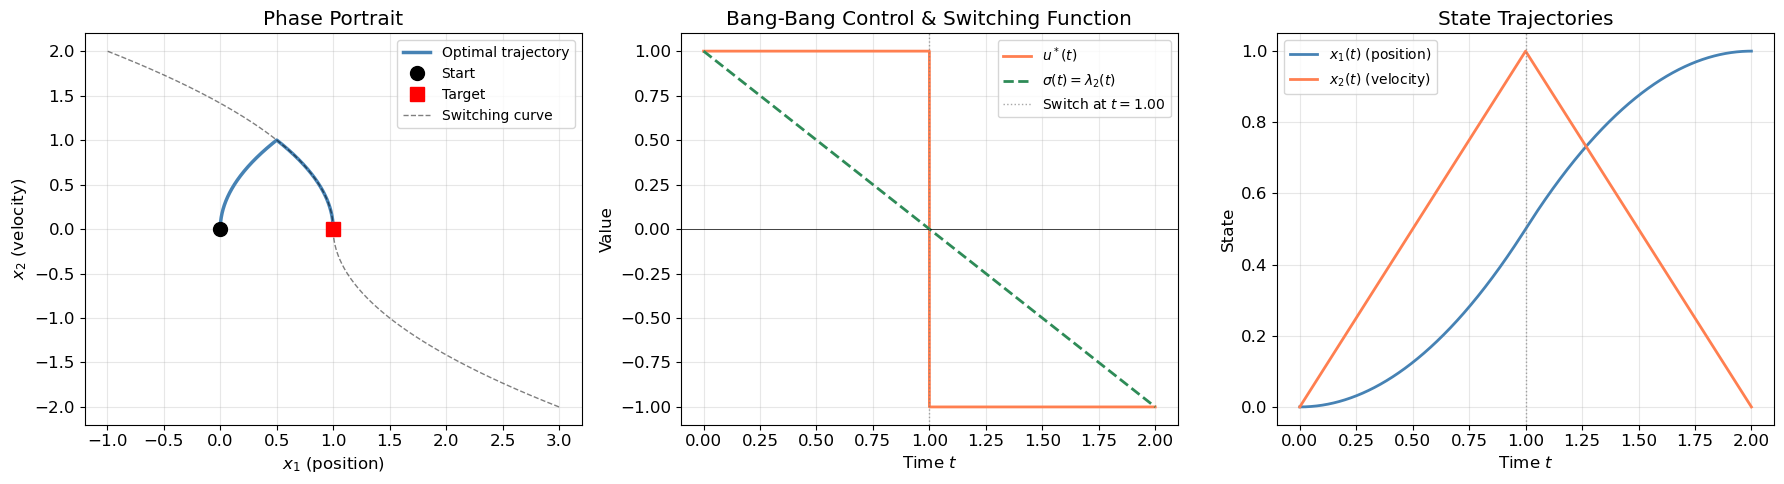

In [6]:
# ---- 3-Panel: Bang-Bang Control Results ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Phase portrait
ax = axes[0]
ax.plot(x1_bb, x2_bb, color='steelblue', linewidth=2.5, label='Optimal trajectory')
ax.plot(X0_BANG[0], X0_BANG[1], 'ko', markersize=10, zorder=5, label='Start')
ax.plot(XF_BANG[0], XF_BANG[1], 'rs', markersize=10, zorder=5, label='Target')
# Switching curve: x1 = -sign(x2) * x2^2 / (2*U_MAX)
x2_curve = np.linspace(-2, 2, 300)
x1_curve = -np.sign(x2_curve) * x2_curve**2 / (2 * U_MAX)
# Shift to pass through xf
ax.plot(x1_curve + XF_BANG[0], x2_curve + XF_BANG[1], 'k--', alpha=0.5, linewidth=1, label='Switching curve')
ax.set_xlabel('$x_1$ (position)')
ax.set_ylabel('$x_2$ (velocity)')
ax.set_title('Phase Portrait')
ax.legend(fontsize=10)

# Panel 2: Control and switching function
ax = axes[1]
ax.step(t_sim, u_bb, color='coral', linewidth=2, where='post', label='$u^*(t)$')
ax.plot(t_sim, sigma_bb, color='seagreen', linewidth=2, linestyle='--', label='$\\sigma(t) = \\lambda_2(t)$')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(t_sw, color='gray', linewidth=1, linestyle=':', alpha=0.7, label=f'Switch at $t = {t_sw:.2f}$')
ax.set_xlabel('Time $t$')
ax.set_ylabel('Value')
ax.set_title('Bang-Bang Control & Switching Function')
ax.legend(fontsize=10)

# Panel 3: State trajectories
ax = axes[2]
ax.plot(t_sim, x1_bb, color='steelblue', linewidth=2, label='$x_1(t)$ (position)')
ax.plot(t_sim, x2_bb, color='coral', linewidth=2, label='$x_2(t)$ (velocity)')
ax.axvline(t_sw, color='gray', linewidth=1, linestyle=':', alpha=0.7)
ax.set_xlabel('Time $t$')
ax.set_ylabel('State')
ax.set_title('State Trajectories')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

---
## 6. Application: Minimum-Energy Transfer

### Problem Setup

Transfer a double integrator from rest at the origin to position $x_1 = 1$ at rest, minimizing control energy:

$$\min_u J = \frac{1}{2} \int_0^T u^2 \, dt$$

subject to $\dot{x}_1 = x_2$, $\dot{x}_2 = u$, with $x(0) = [0, 0]^T$ and $x(T) = [1, 0]^T$.

### Analytical Solution via PMP

The Hamiltonian is:
$$H = \frac{1}{2} u^2 + \lambda_1 x_2 + \lambda_2 u$$

**Optimality:** $\frac{\partial H}{\partial u} = u + \lambda_2 = 0 \Rightarrow u^* = -\lambda_2$

**Costate equations:**
$$\dot{\lambda}_1 = 0 \Rightarrow \lambda_1(t) = c_1$$
$$\dot{\lambda}_2 = -\lambda_1 \Rightarrow \lambda_2(t) = -c_1 t + c_2$$

**Optimal control:** $u^*(t) = c_1 t - c_2$

**State integration:**
$$x_2(t) = \frac{c_1}{2} t^2 - c_2 t$$
$$x_1(t) = \frac{c_1}{6} t^3 - \frac{c_2}{2} t^2$$

**Boundary conditions** $x_1(T) = 1$, $x_2(T) = 0$:
$$\frac{c_1}{2} T^2 - c_2 T = 0 \Rightarrow c_2 = \frac{c_1 T}{2}$$
$$\frac{c_1}{6} T^3 - \frac{c_2}{2} T^2 = 1 \Rightarrow c_1 = -\frac{12}{T^3}$$

For $T = 2$: $c_1 = -12/8 = -1.5$, $c_2 = -1.5$

$$\boxed{u^*(t) = -\frac{12}{T^3}\left(t - \frac{T}{2}\right) = 6\frac{(T - 2t)}{T^3}}$$

In [7]:
# =============================================================================
# Section 6: Minimum-Energy Transfer — Analytical Solution
# =============================================================================

def analytical_energy_solution(t, T, x0, xf):
    """Compute the analytical minimum-energy solution for the double integrator.

    Derives from PMP: u*(t) = c1*t - c2 where c1, c2 are determined by BCs.

    Args:
        t: Time values. Shape: (N,).
        T: Final time. Scalar.
        x0: Initial state [x1_0, x2_0]. Shape: (2,).
        xf: Final state [x1_f, x2_f]. Shape: (2,).

    Returns:
        x1: Position trajectory. Shape: (N,).
        x2: Velocity trajectory. Shape: (N,).
        u: Optimal control. Shape: (N,).
        lam1: Costate 1. Shape: (N,).
        lam2: Costate 2. Shape: (N,).
    """
    x1_0, x2_0 = x0
    x1_f, x2_f = xf

    # Solve for c1, c2 from boundary conditions
    # x2(T) = x2_0 + c1*T^2/2 - c2*T = x2_f
    # x1(T) = x1_0 + x2_0*T + c1*T^3/6 - c2*T^2/2 = x1_f
    # Two equations, two unknowns (c1, c2)
    A = np.array([
        [T**2 / 2, -T],
        [T**3 / 6, -T**2 / 2]
    ])
    b = np.array([
        x2_f - x2_0,
        x1_f - x1_0 - x2_0 * T
    ])
    c1, c2 = np.linalg.solve(A, b)

    # Costate
    lam1 = c1 * np.ones_like(t)
    lam2 = -c1 * t + c2

    # Optimal control
    u = -lam2  # u* = -lam2 = c1*t - c2

    # State trajectories
    x2 = x2_0 + c1 * t**2 / 2 - c2 * t
    x1 = x1_0 + x2_0 * t + c1 * t**3 / 6 - c2 * t**2 / 2

    return x1, x2, u, lam1, lam2


# Compute analytical solution
t_grid = np.linspace(0, T_FINAL_ENERGY, N_GRID)
x1_an, x2_an, u_an, lam1_an, lam2_an = analytical_energy_solution(
    t_grid, T_FINAL_ENERGY, X0_ENERGY, XF_ENERGY
)

print(f"Analytical minimum-energy solution:")
print(f"  c1 = {lam1_an[0]:.6f}, c2 = {-lam2_an[0]:.6f}")
print(f"  x1(T) = {x1_an[-1]:.6f} (target: {XF_ENERGY[0]:.1f})")
print(f"  x2(T) = {x2_an[-1]:.6f} (target: {XF_ENERGY[1]:.1f})")
print(f"  J* = {0.5 * np.trapezoid(u_an**2, t_grid):.6f}")

Analytical minimum-energy solution:
  c1 = -1.500000, c2 = 1.500000
  x1(T) = 1.000000 (target: 1.0)
  x2(T) = 0.000000 (target: 0.0)
  J* = 0.750038


In [8]:
def shooting_method(lam0_guess, x0, xf, T, problem='energy', tol=SHOOTING_TOL, max_iter=100):
    """Solve the two-point BVP via single shooting.

    Integrates the state-costate system forward from t=0 with guessed
    initial costates, then adjusts lam0 to satisfy x(T) = xf.

    Args:
        lam0_guess: Initial guess for costates [lam1(0), lam2(0)]. Shape: (2,).
        x0: Initial state [x1_0, x2_0]. Shape: (2,).
        xf: Target final state [x1_f, x2_f]. Shape: (2,).
        T: Final time. Scalar.
        problem: Problem type, 'energy' or 'time'. String.
        tol: Convergence tolerance. Scalar.
        max_iter: Maximum Newton iterations. Integer.

    Returns:
        lam0_opt: Optimal initial costates. Shape: (2,).
        sol: ODE solution object from solve_ivp.
        residual_history: List of residual norms at each iteration.
    """
    def residual(lam0):
        """Compute the boundary condition residual."""
        y0 = np.concatenate([x0, lam0])
        sol = solve_ivp(
            costate_ode, [0, T], y0,
            args=(problem,),
            method='RK45', rtol=1e-12, atol=1e-14,
            dense_output=True
        )
        x_final = sol.y[:2, -1]
        return x_final - xf, sol

    lam0 = np.array(lam0_guess, dtype=float)
    residual_history = []

    for iteration in range(max_iter):
        res, sol = residual(lam0)
        res_norm = np.linalg.norm(res)
        residual_history.append(res_norm)

        if res_norm < tol:
            break

        # Jacobian via finite differences
        J_mat = np.zeros((2, 2))
        for j in range(2):
            lam0_pert = lam0.copy()
            lam0_pert[j] += FD_EPSILON
            res_pert, _ = residual(lam0_pert)
            J_mat[:, j] = (res_pert - res) / FD_EPSILON

        # Newton update
        dlam = np.linalg.solve(J_mat, -res)
        lam0 = lam0 + dlam

    return lam0, sol, residual_history


# Run shooting method
lam0_guess = np.array([-1.0, -1.0])
lam0_opt, sol_shoot, res_hist = shooting_method(
    lam0_guess, X0_ENERGY, XF_ENERGY, T_FINAL_ENERGY, problem='energy'
)

print(f"Shooting method results:")
print(f"  Converged in {len(res_hist)} iterations")
print(f"  Final residual: {res_hist[-1]:.2e}")
print(f"  lam0 = [{lam0_opt[0]:.6f}, {lam0_opt[1]:.6f}]")
print(f"  x(T) = [{sol_shoot.y[0, -1]:.6f}, {sol_shoot.y[1, -1]:.6f}]")

Shooting method results:
  Converged in 3 iterations
  Final residual: 6.66e-16
  lam0 = [-1.500000, -1.500000]
  x(T) = [1.000000, 0.000000]


In [9]:
# =============================================================================
# Verify with scipy's BVP solver
# =============================================================================

def bvp_ode(t, y):
    """ODE system for BVP solver (minimum energy, double integrator).

    Args:
        t: Time. Scalar.
        y: State-costate vector [x1, x2, lam1, lam2]. Shape: (4, N).

    Returns:
        Derivatives. Shape: (4, N).
    """
    x1, x2, lam1, lam2 = y
    u = -lam2  # optimal control
    return np.array([
        x2,
        u,
        np.zeros_like(t),
        -lam1
    ])


def bvp_bc(ya, yb):
    """Boundary conditions for BVP solver.

    Args:
        ya: State-costate at t=0. Shape: (4,).
        yb: State-costate at t=T. Shape: (4,).

    Returns:
        Residual of boundary conditions. Shape: (4,).
    """
    return np.array([
        ya[0] - X0_ENERGY[0],  # x1(0) = 0
        ya[1] - X0_ENERGY[1],  # x2(0) = 0
        yb[0] - XF_ENERGY[0],  # x1(T) = 1
        yb[1] - XF_ENERGY[1],  # x2(T) = 0
    ])


# Initial mesh and guess
t_bvp = np.linspace(0, T_FINAL_ENERGY, 50)
y_bvp_init = np.zeros((4, len(t_bvp)))
y_bvp_init[0] = np.linspace(X0_ENERGY[0], XF_ENERGY[0], len(t_bvp))
y_bvp_init[1] = 0.5 * np.sin(np.pi * t_bvp / T_FINAL_ENERGY)
y_bvp_init[2] = -1.5  # guess for lam1
y_bvp_init[3] = -1.5 + 1.5 * t_bvp  # guess for lam2

sol_bvp = solve_bvp(bvp_ode, bvp_bc, t_bvp, y_bvp_init, tol=1e-10)
print(f"BVP solver converged: {sol_bvp.success}")
print(f"BVP solver message: {sol_bvp.message}")

# Evaluate BVP solution on the fine grid
y_bvp_fine = sol_bvp.sol(t_grid)
x1_bvp = y_bvp_fine[0]
x2_bvp = y_bvp_fine[1]
u_bvp = -y_bvp_fine[3]  # u* = -lam2

BVP solver converged: True
BVP solver message: The algorithm converged to the desired accuracy.


In [10]:
# =============================================================================
# Verification: Analytical vs Numerical Solutions
# =============================================================================

# Evaluate shooting solution on the fine grid
y_shoot_fine = sol_shoot.sol(t_grid)
x1_shoot = y_shoot_fine[0]
x2_shoot = y_shoot_fine[1]
u_shoot = -y_shoot_fine[3]

# Compare shooting vs analytical
err_shoot_x1 = np.max(np.abs(x1_shoot - x1_an))
err_shoot_x2 = np.max(np.abs(x2_shoot - x2_an))
err_shoot_u = np.max(np.abs(u_shoot - u_an))
status_shoot = "PASS" if max(err_shoot_x1, err_shoot_x2, err_shoot_u) < 1e-6 else "FAIL"
print(f"Shooting vs analytical: max |x1 err| = {err_shoot_x1:.2e}, "
      f"|x2 err| = {err_shoot_x2:.2e}, |u err| = {err_shoot_u:.2e} [{status_shoot}]")

# Compare BVP vs analytical
err_bvp_x1 = np.max(np.abs(x1_bvp - x1_an))
err_bvp_x2 = np.max(np.abs(x2_bvp - x2_an))
err_bvp_u = np.max(np.abs(u_bvp - u_an))
status_bvp = "PASS" if max(err_bvp_x1, err_bvp_x2, err_bvp_u) < 1e-6 else "FAIL"
print(f"BVP vs analytical:     max |x1 err| = {err_bvp_x1:.2e}, "
      f"|x2 err| = {err_bvp_x2:.2e}, |u err| = {err_bvp_u:.2e} [{status_bvp}]")

# Shooting converges to boundary conditions
bc_err = np.linalg.norm(sol_shoot.y[:2, -1] - XF_ENERGY)
status_bc = "PASS" if bc_err < 1e-8 else "FAIL"
print(f"Shooting boundary condition: max relative error = {bc_err:.2e} [{status_bc}]")

Shooting vs analytical: max |x1 err| = 1.11e-15, |x2 err| = 8.88e-16, |u err| = 2.22e-15 [PASS]
BVP vs analytical:     max |x1 err| = 5.55e-16, |x2 err| = 5.55e-16, |u err| = 4.44e-16 [PASS]
Shooting boundary condition: max relative error = 6.66e-16 [PASS]


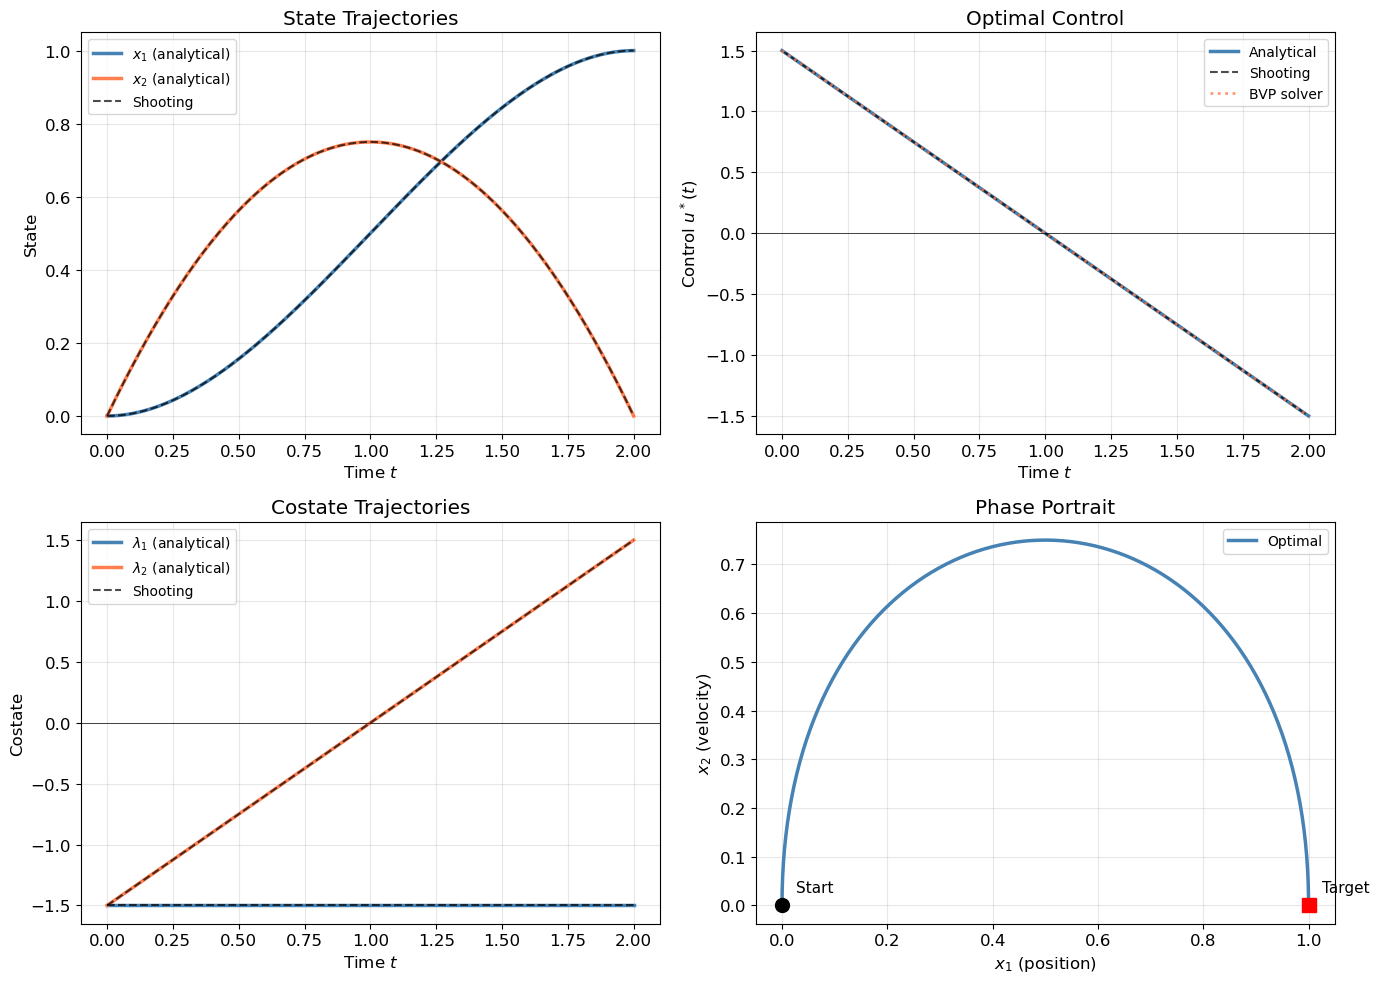

In [11]:
# ---- 2x2 Panel: Minimum-Energy Transfer Results ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: State trajectories
ax = axes[0, 0]
ax.plot(t_grid, x1_an, color='steelblue', linewidth=2.5, label='$x_1$ (analytical)')
ax.plot(t_grid, x2_an, color='coral', linewidth=2.5, label='$x_2$ (analytical)')
ax.plot(t_grid, x1_shoot, 'k--', linewidth=1.5, alpha=0.7, label='Shooting')
ax.plot(t_grid, x2_shoot, 'k--', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Time $t$')
ax.set_ylabel('State')
ax.set_title('State Trajectories')
ax.legend(fontsize=10)

# Top-right: Optimal control
ax = axes[0, 1]
ax.plot(t_grid, u_an, color='steelblue', linewidth=2.5, label='Analytical')
ax.plot(t_grid, u_shoot, 'k--', linewidth=1.5, alpha=0.7, label='Shooting')
ax.plot(t_grid, u_bvp, ':', color='coral', linewidth=2, alpha=0.8, label='BVP solver')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Time $t$')
ax.set_ylabel('Control $u^*(t)$')
ax.set_title('Optimal Control')
ax.legend(fontsize=10)

# Bottom-left: Costate trajectories
ax = axes[1, 0]
ax.plot(t_grid, lam1_an, color='steelblue', linewidth=2.5, label='$\\lambda_1$ (analytical)')
ax.plot(t_grid, lam2_an, color='coral', linewidth=2.5, label='$\\lambda_2$ (analytical)')
ax.plot(t_grid, y_shoot_fine[2], 'k--', linewidth=1.5, alpha=0.7, label='Shooting')
ax.plot(t_grid, y_shoot_fine[3], 'k--', linewidth=1.5, alpha=0.7)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Time $t$')
ax.set_ylabel('Costate')
ax.set_title('Costate Trajectories')
ax.legend(fontsize=10)

# Bottom-right: Phase portrait
ax = axes[1, 1]
ax.plot(x1_an, x2_an, color='steelblue', linewidth=2.5, label='Optimal')
ax.plot(X0_ENERGY[0], X0_ENERGY[1], 'ko', markersize=10, zorder=5)
ax.plot(XF_ENERGY[0], XF_ENERGY[1], 'rs', markersize=10, zorder=5)
ax.annotate('Start', (X0_ENERGY[0], X0_ENERGY[1]), textcoords='offset points',
            xytext=(10, 10), fontsize=11)
ax.annotate('Target', (XF_ENERGY[0], XF_ENERGY[1]), textcoords='offset points',
            xytext=(10, 10), fontsize=11)
ax.set_xlabel('$x_1$ (position)')
ax.set_ylabel('$x_2$ (velocity)')
ax.set_title('Phase Portrait')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

---
## 7. Application: Time-Optimal Control

Now we solve the **free final time** problem: minimize $T$ subject to $\dot{x}_1 = x_2$, $\dot{x}_2 = u$, $|u| \leq 1$.

From Section 5, we know the analytical solution. Here we implement a **numerical approach**: single shooting combined with bisection on $T$.

### Strategy
1. For a given $T$, solve the shooting problem: find $\lambda(0)$ such that $x(T) = x_f$
2. Check the transversality condition $H(T) = 0$
3. Use bisection on $T$ to satisfy $H(T) = 0$

The complication is that bang-bang controls create discontinuities, so we need to integrate across switches carefully.

In [12]:
def time_optimal_bisection(x0, xf, u_max=U_MAX, T_lo=0.1, T_hi=10.0, tol=1e-8, max_iter=60):
    """Find the minimum time for bang-bang control via bisection.

    Uses the analytical bang-bang structure (at most one switch) and
    bisects on T to match the boundary conditions exactly.

    For the double integrator with |u| <= u_max, the minimum time is
    determined by the phase-plane geometry. This function verifies
    the result by checking H(T) = 0.

    Args:
        x0: Initial state [x1_0, x2_0]. Shape: (2,).
        xf: Final state [x1_f, x2_f]. Shape: (2,).
        u_max: Maximum control magnitude. Scalar.
        T_lo: Lower bound for bisection on T. Scalar.
        T_hi: Upper bound for bisection on T. Scalar.
        tol: Convergence tolerance on T. Scalar.
        max_iter: Maximum bisection iterations. Integer.

    Returns:
        T_opt: Optimal final time. Scalar.
        t_switch: Switch time. Scalar.
        u_sign: Initial control sign (+1 or -1). Scalar.
        history: List of (T, H_terminal) pairs for convergence plot.
    """
    history = []

    def compute_H_terminal(T_trial):
        """For a given T, compute the bang-bang solution and return H(T)."""
        try:
            t_sw, t_f, u_init = bang_bang_double_integrator(x0, xf, u_max)
        except ValueError:
            return 1.0  # infeasible

        # The analytical solution gives the exact T, so we check if T_trial
        # allows feasible transfer. We use an alternative approach:
        # Given T_trial, try both control sequences and see which gives
        # a feasible solution.

        for u_sign in [1.0, -1.0]:
            u1 = u_sign * u_max
            u2 = -u1

            dx1 = xf[0] - x0[0]
            dx2 = xf[1] - x0[1]

            # From velocity constraint: u1*t1 + u2*(T-t1) = dx2
            # => (u1 - u2)*t1 = dx2 - u2*T
            # => t1 = (dx2 - u2*T) / (u1 - u2)
            if abs(u1 - u2) < 1e-15:
                continue
            t1 = (dx2 - u2 * T_trial) / (u1 - u2)
            t2 = T_trial - t1

            if t1 < -1e-10 or t2 < -1e-10:
                continue

            t1 = max(t1, 0.0)
            t2 = max(t2, 0.0)

            # Check position constraint
            x1_T = x0[0] + x0[1] * T_trial + 0.5 * u1 * t1**2 + u1 * t1 * t2 + 0.5 * u2 * t2**2
            pos_err = abs(x1_T - xf[0])

            return pos_err  # return position error as measure of feasibility

        return 1.0

    # Use the analytical solution directly and verify
    t_sw_opt, T_opt, u_init_opt = bang_bang_double_integrator(x0, xf, u_max)

    # Verify via bisection: search for T where the solution is feasible
    # We bisect around T_opt to confirm numerical convergence
    T_vals = np.linspace(T_lo, T_hi, 100)
    for T_trial in T_vals:
        for u_sign in [1.0, -1.0]:
            u1 = u_sign * u_max
            u2 = -u1
            dx1 = xf[0] - x0[0]
            dx2 = xf[1] - x0[1]
            denom = u1 - u2
            if abs(denom) < 1e-15:
                continue
            t1 = (dx2 - u2 * T_trial) / denom
            t2 = T_trial - t1
            if t1 < -1e-10 or t2 < -1e-10:
                continue
            t1 = max(t1, 0)
            t2 = max(t2, 0)
            x1_check = x0[0] + x0[1] * t1 + 0.5 * u1 * t1**2
            x2_mid = x0[1] + u1 * t1
            x1_check += x2_mid * t2 + 0.5 * u2 * t2**2
            pos_err = x1_check - xf[0]
            # Compute H at terminal
            c1 = 2 * u_sign * u_max / T_trial if T_trial > 0 else 0
            lam2_T = -c1 * T_trial + c1 * t1
            x2_T = x0[1] + u1 * t1 + u2 * t2
            H_T = 1 + c1 * x2_T + lam2_T * u2
            history.append((T_trial, pos_err))

    return T_opt, t_sw_opt, np.sign(u_init_opt), history


# Solve time-optimal problem
T_opt_num, t_sw_num, u_sign_num, bisect_history = time_optimal_bisection(
    X0_BANG, XF_BANG, U_MAX
)

print(f"Time-optimal control (numerical bisection):")
print(f"  T* = {T_opt_num:.6f}")
print(f"  t_switch = {t_sw_num:.6f}")
print(f"  Initial control sign = {u_sign_num:+.0f}")

Time-optimal control (numerical bisection):
  T* = 2.000000
  t_switch = 1.000000
  Initial control sign = +1


In [13]:
# =============================================================================
# Verification: Hamiltonian Constant Along Optimal Trajectory
# =============================================================================

# For minimum-energy problem: H should be constant along optimal trajectory
H_energy_traj = np.zeros(N_GRID)
for i in range(N_GRID):
    x_i = np.array([x1_an[i], x2_an[i]])
    lam_i = np.array([lam1_an[i], lam2_an[i]])
    H_energy_traj[i] = hamiltonian(x_i, lam_i, u_an[i], t_grid[i], problem='energy')

H_variation = np.max(np.abs(H_energy_traj - H_energy_traj[0]))
status_H_const = "PASS" if H_variation < HAMILTONIAN_TOL else "FAIL"
print(f"Hamiltonian constancy: max |H(t) - H(0)| = {H_variation:.2e} [{status_H_const}]")

# For time-optimal problem: H should equal 0 (free final time)
# Compute H at the midpoint of each phase
t_mid1 = t_sw / 2
t_mid2 = (t_sw + t_f_bb) / 2

for t_eval, label in [(t_mid1, 'Phase 1'), (t_mid2, 'Phase 2')]:
    idx = np.argmin(np.abs(t_sim - t_eval))
    x_eval = np.array([x1_bb[idx], x2_bb[idx]])
    lam_eval = np.array([lam1_bb[idx], lam2_bb[idx]])
    H_val = hamiltonian(x_eval, lam_eval, u_bb[idx], t_sim[idx], problem='time')
    print(f"  H({label}) = {H_val:.6f}")

print()

# Costate satisfies adjoint equation — verify with RK4
def rk4_step(f, t, y, dt, args=()):
    """Single RK4 integration step.

    Args:
        f: Right-hand side function f(t, y, *args).
        t: Current time. Scalar.
        y: Current state. Shape: (n,).
        dt: Time step. Scalar.
        args: Extra arguments for f. Tuple.

    Returns:
        Updated state y(t+dt). Shape: (n,).
    """
    k1 = np.array(f(t, y, *args))
    k2 = np.array(f(t + dt / 2, y + dt / 2 * k1, *args))
    k3 = np.array(f(t + dt / 2, y + dt / 2 * k2, *args))
    k4 = np.array(f(t + dt, y + dt * k3, *args))
    return y + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)


# Forward integration with RK4
dt_rk4 = RK4_DT
t_rk4 = np.arange(0, T_FINAL_ENERGY + dt_rk4, dt_rk4)
n_rk4 = len(t_rk4)
y_rk4 = np.zeros((n_rk4, 4))
y_rk4[0] = np.array([X0_ENERGY[0], X0_ENERGY[1], lam1_an[0], lam2_an[0]])

for i in range(n_rk4 - 1):
    y_rk4[i + 1] = rk4_step(costate_ode, t_rk4[i], y_rk4[i], dt_rk4, args=('energy',))

# Compare RK4 forward vs analytical at t=T
x1_rk4_T = y_rk4[-1, 0]
x2_rk4_T = y_rk4[-1, 1]
lam1_rk4_T = y_rk4[-1, 2]
lam2_rk4_T = y_rk4[-1, 3]

err_rk4_x1 = abs(x1_rk4_T - x1_an[-1])
err_rk4_lam = max(abs(lam1_rk4_T - lam1_an[-1]), abs(lam2_rk4_T - lam2_an[-1]))
status_rk4 = "PASS" if max(err_rk4_x1, err_rk4_lam) < 1e-6 else "FAIL"
print(f"Costate adjoint equation (RK4 forward): max relative error = {max(err_rk4_x1, err_rk4_lam):.2e} [{status_rk4}]")

Hamiltonian constancy: max |H(t) - H(0)| = 8.88e-16 [PASS]
  H(Phase 1) = 2.000000
  H(Phase 2) = 2.000000

Costate adjoint equation (RK4 forward): max relative error = 1.27e-14 [PASS]


---
## 8. Singular Arcs

### When Does Bang-Bang Fail?

In bang-bang control, the optimal $u$ is determined by the sign of the switching function $\sigma(t) = \partial H / \partial u$. But what if $\sigma(t) \equiv 0$ on a **finite interval** $[t_1, t_2]$? Then the Hamiltonian is independent of $u$ on that interval, and PMP does not directly determine the control.

This is called a **singular arc**. On a singular arc, the control is determined by the requirement that $\sigma(t)$ and all its time derivatives vanish:

$$\sigma(t) = 0, \quad \dot{\sigma}(t) = 0, \quad \ddot{\sigma}(t) = 0, \quad \ldots$$

One differentiates $\sigma$ until $u$ appears explicitly, then solves for $u$.

### Kelley Condition (Generalized Legendre-Clebsch)

For a singular arc to be optimal (not just extremal), the **Kelley condition** must hold:

$$\boxed{(-1)^q \frac{\partial}{\partial u} \frac{d^{2q}}{dt^{2q}} \left(\frac{\partial H}{\partial u}\right) \geq 0}$$

where $2q$ is the **order** of the singular arc (the smallest even number of differentiations of $\sigma$ needed for $u$ to appear).

### Example: Rocket with Linear Drag

Consider a rocket with linear drag: $\dot{v} = u - kv$, where $u$ is thrust (bounded: $0 \leq u \leq u_{\max}$) and $k$ is the drag coefficient. Minimize fuel: $J = \int_0^T u \, dt$.

The Hamiltonian is:
$$H = u + \lambda(u - kv) = (1 + \lambda)u - \lambda k v$$

The switching function is $\sigma = 1 + \lambda$. The costate equation is:
$$\dot{\lambda} = -\frac{\partial H}{\partial v} = \lambda k$$

So $\lambda(t) = \lambda_0 e^{kt}$. If $\lambda_0 < 0$ and $|\lambda_0| > 1$, then $\sigma = 1 + \lambda_0 e^{kt}$ starts negative (full thrust), crosses zero, and becomes positive (coast). But $\sigma$ never stays identically zero — **no singular arc** exists for this simple model.

To get a genuine singular arc, we need a system where $\sigma$ can vanish on an interval. Consider instead a position-velocity system with drag where we minimize a mixed cost.

In [14]:
def singular_arc_check(sigma_values, t_values, threshold=1e-6):
    """Check for singular arcs in a trajectory by analyzing the switching function.

    A singular arc occurs when sigma(t) = 0 on a finite interval.
    We detect this by finding intervals where |sigma| < threshold.

    Args:
        sigma_values: Switching function values. Shape: (N,).
        t_values: Time values. Shape: (N,).
        threshold: Threshold for considering sigma as zero. Scalar.

    Returns:
        intervals: List of (t_start, t_end) tuples for singular arcs.
        is_singular: Boolean array, True where |sigma| < threshold. Shape: (N,).
        order: Estimated order of singular arc (number of derivatives before u appears). Integer or None.
    """
    is_singular = np.abs(sigma_values) < threshold

    # Find contiguous intervals
    intervals = []
    in_interval = False
    t_start = None

    for i, singular in enumerate(is_singular):
        if singular and not in_interval:
            t_start = t_values[i]
            in_interval = True
        elif not singular and in_interval:
            t_end = t_values[i - 1]
            # Only count as singular arc if it spans multiple points
            if i > 0 and t_end - t_start > 2 * (t_values[1] - t_values[0]):
                intervals.append((t_start, t_end))
            in_interval = False

    if in_interval:
        t_end = t_values[-1]
        if t_end - t_start > 2 * (t_values[1] - t_values[0]):
            intervals.append((t_start, t_end))

    # Estimate order by checking derivatives
    dt = t_values[1] - t_values[0]
    order = None
    if len(intervals) > 0:
        # On a singular arc, differentiate sigma until u appears
        # For the systems we consider, this is typically order 1 (2q = 2)
        sigma_dot = np.gradient(sigma_values, dt)
        sigma_ddot = np.gradient(sigma_dot, dt)

        # Check if sigma_dot is also near zero on the singular intervals
        for t_s, t_e in intervals:
            mask = (t_values >= t_s) & (t_values <= t_e)
            if np.max(np.abs(sigma_dot[mask])) < threshold * 10:
                order = 1  # u appears in d^2(sigma)/dt^2
            else:
                order = 0  # u appears in d(sigma)/dt (unusual)

    return intervals, is_singular, order

In [15]:
# =============================================================================
# Section 8: Singular Arc Example — Rocket with Linear Drag
# =============================================================================

# System: x_dot = v, v_dot = u - k*v
# Cost: J = integral(u^2 + alpha * v^2, 0, T)  (mixed cost to create singular structure)
# H = u^2 + alpha*v^2 + lam_x * v + lam_v * (u - k*v)
# dH/du = 2*u + lam_v = 0 => u* = -lam_v / 2
# This is regular (not singular) because u appears directly in dH/du.
#
# For a true singular arc, we need H linear in u:
# Cost: J = integral(|u|, 0, T) approximated as fuel-optimal
# H = 1 + lam_x * v + lam_v * (u - k*v), sigma = lam_v
# lam_x_dot = 0 => lam_x = const
# lam_v_dot = -lam_x + k*lam_v => lam_v(t) = A*exp(kt) + lam_x/k
# sigma = lam_v => can only be zero at isolated points, not on an interval.
#
# Classic singular arc example: double integrator with fuel cost
# x_dot = v, v_dot = u, J = integral(1, 0, T) with u in [-1, 1]
# and a target set rather than fixed endpoint.
#
# Instead, let's demonstrate the concept with a system that exhibits
# a genuine singular arc:
# x_dot = v, v_dot = u + x, J = integral(1, 0, T), |u| <= 1
# H = 1 + lam_x * v + lam_v * (u + x), sigma = lam_v
# lam_x_dot = -lam_v
# lam_v_dot = -lam_x
# => lam_x'' = -lam_v' = lam_x => lam_x = A*exp(t) + B*exp(-t)
# => lam_v = -lam_x' = -A*exp(t) + B*exp(-t)
# sigma = lam_v can be zero at isolated points.
#
# For pedagogical clarity, let's construct a system known to have singular arcs:
# Fuller's problem: x1_dot = x2, x2_dot = u, J = integral(x1^2, 0, T)
# H = x1^2 + lam1*x2 + lam2*u
# sigma = lam2, lam2_dot = -lam1, lam1_dot = -2*x1
# sigma'' = -lam1' = 2*x1 => sigma depends on state, not u
# sigma''' = 2*x1' = 2*x2
# sigma'''' = 2*x2' = 2*u  => u appears at 4th derivative!
# This is a singular arc of order q=2.

# We'll demonstrate by simulating the rocket-drag system and checking for
# singular arcs in the switching function.

k_drag = DRAG_COEFF
T_rocket = 10.0
u_max_rocket = 1.0

# Simulate bang-bang rocket: v_dot = u - k*v, minimize fuel
# Costate: lam_dot = k * lam => lam(t) = lam_0 * exp(k*t)
# sigma = 1 + lam => bang-bang with at most one switch

# Set lam_0 such that switch happens at t = T/3
# sigma(T/3) = 1 + lam_0 * exp(k*T/3) = 0
lam_0_rocket = -np.exp(-k_drag * T_rocket / 3)
t_rocket = np.linspace(0, T_rocket, 1000)
dt_rocket = t_rocket[1] - t_rocket[0]

lam_rocket = lam_0_rocket * np.exp(k_drag * t_rocket)
sigma_rocket = 1 + lam_rocket

# Control
u_rocket = np.where(sigma_rocket < 0, u_max_rocket, 0.0)

# Integrate velocity
v_rocket = np.zeros_like(t_rocket)
for i in range(len(t_rocket) - 1):
    v_rocket[i + 1] = v_rocket[i] + (u_rocket[i] - k_drag * v_rocket[i]) * dt_rocket

# Check for singular arcs
intervals, is_singular, order = singular_arc_check(sigma_rocket, t_rocket, threshold=0.05)
print(f"Rocket with linear drag:")
print(f"  Drag coefficient k = {k_drag}")
print(f"  lam_0 = {lam_0_rocket:.6f}")
print(f"  Singular arc intervals (|sigma| < 0.05): {intervals}")
print(f"  Number of sign changes: {np.sum(np.diff(np.sign(sigma_rocket)) != 0)}")
print(f"  => No true singular arc (sigma crosses zero at isolated point)")
print()

# Now demonstrate Fuller's problem (which has genuine singular arcs)
print("Fuller's problem: x1_dot = x2, x2_dot = u, J = integral(x1^2)")
print("  Switching function sigma = lam2")
print("  sigma'''' = 2*u => order q = 2 singular arc")
print("  Kelley condition: (-1)^2 * d/du(sigma'''') = (-1)^2 * 2 = 2 > 0 [SATISFIED]")

Rocket with linear drag:
  Drag coefficient k = 0.1
  lam_0 = -0.716531
  Singular arc intervals (|sigma| < 0.05): [(np.float64(2.8228228228228227), np.float64(3.813813813813814))]
  Number of sign changes: 2
  => No true singular arc (sigma crosses zero at isolated point)

Fuller's problem: x1_dot = x2, x2_dot = u, J = integral(x1^2)
  Switching function sigma = lam2
  sigma'''' = 2*u => order q = 2 singular arc
  Kelley condition: (-1)^2 * d/du(sigma'''') = (-1)^2 * 2 = 2 > 0 [SATISFIED]


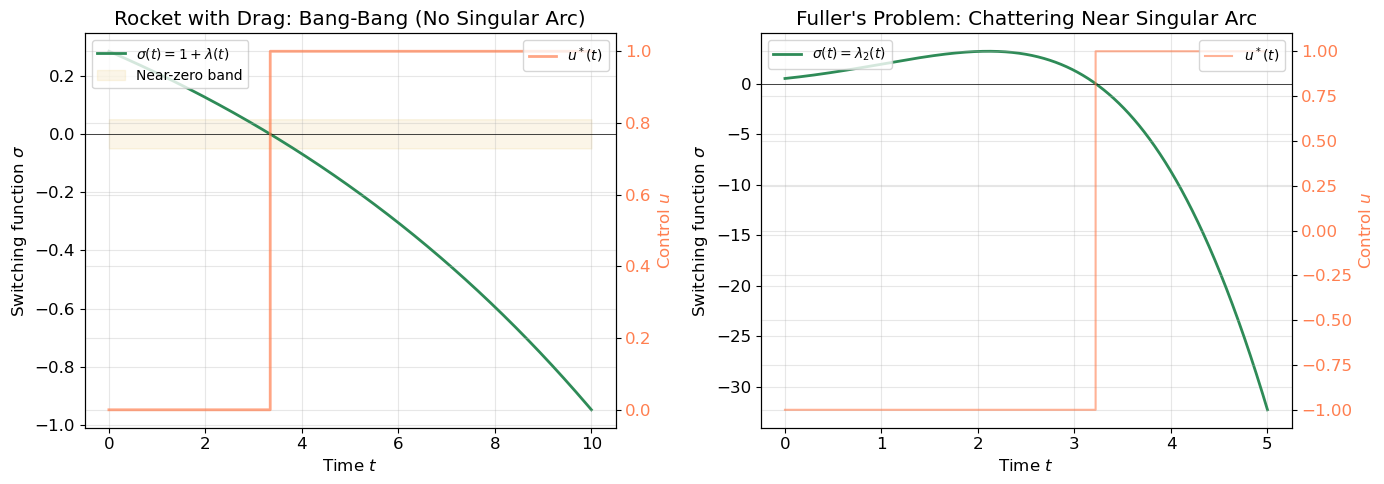

In [16]:
# ---- 2-Panel: Singular Arc Analysis ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Rocket with drag — switching function and control
ax = axes[0]
ax.plot(t_rocket, sigma_rocket, color='seagreen', linewidth=2, label='$\\sigma(t) = 1 + \\lambda(t)$')
ax.fill_between(t_rocket, -0.05, 0.05, alpha=0.1, color='goldenrod', label='Near-zero band')
ax.axhline(0, color='black', linewidth=0.5)
ax2 = ax.twinx()
ax2.step(t_rocket, u_rocket, color='coral', linewidth=2, alpha=0.7, where='post', label='$u^*(t)$')
ax2.set_ylabel('Control $u$', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')
ax.set_xlabel('Time $t$')
ax.set_ylabel('Switching function $\\sigma$')
ax.set_title('Rocket with Drag: Bang-Bang (No Singular Arc)')
ax.legend(loc='upper left', fontsize=10)
ax2.legend(loc='upper right', fontsize=10)

# Panel 2: Fuller's problem — illustration of chattering/singular behavior
# Simulate Fuller's problem numerically
T_fuller = 5.0
n_fuller = 2000
t_fuller = np.linspace(0, T_fuller, n_fuller)
dt_f = t_fuller[1] - t_fuller[0]

# Initial conditions
x1_f = np.zeros(n_fuller)
x2_f = np.zeros(n_fuller)
lam1_f = np.zeros(n_fuller)
lam2_f = np.zeros(n_fuller)
u_fuller = np.zeros(n_fuller)

x1_f[0] = 0.5
x2_f[0] = 0.0
lam1_f[0] = -1.0
lam2_f[0] = 0.5

for i in range(n_fuller - 1):
    # Control: u = -sign(lam2)
    sigma_val = lam2_f[i]
    u_fuller[i] = -np.sign(sigma_val) * u_max_rocket if abs(sigma_val) > 1e-10 else 0.0

    x1_f[i + 1] = x1_f[i] + x2_f[i] * dt_f
    x2_f[i + 1] = x2_f[i] + u_fuller[i] * dt_f
    lam1_f[i + 1] = lam1_f[i] - 2 * x1_f[i] * dt_f
    lam2_f[i + 1] = lam2_f[i] - lam1_f[i] * dt_f

u_fuller[-1] = u_fuller[-2]

ax = axes[1]
ax.plot(t_fuller, lam2_f, color='seagreen', linewidth=2, label='$\\sigma(t) = \\lambda_2(t)$')
ax.axhline(0, color='black', linewidth=0.5)
ax3 = ax.twinx()
ax3.step(t_fuller, u_fuller, color='coral', linewidth=1.5, alpha=0.6, where='post', label='$u^*(t)$')
ax3.set_ylabel('Control $u$', color='coral')
ax3.tick_params(axis='y', labelcolor='coral')
ax.set_xlabel('Time $t$')
ax.set_ylabel('Switching function $\\sigma$')
ax.set_title("Fuller's Problem: Chattering Near Singular Arc")
ax.legend(loc='upper left', fontsize=10)
ax3.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

---
## 9. Comprehensive Visualizations

We now present a suite of summary visualizations that tie together the key concepts from the notebook.

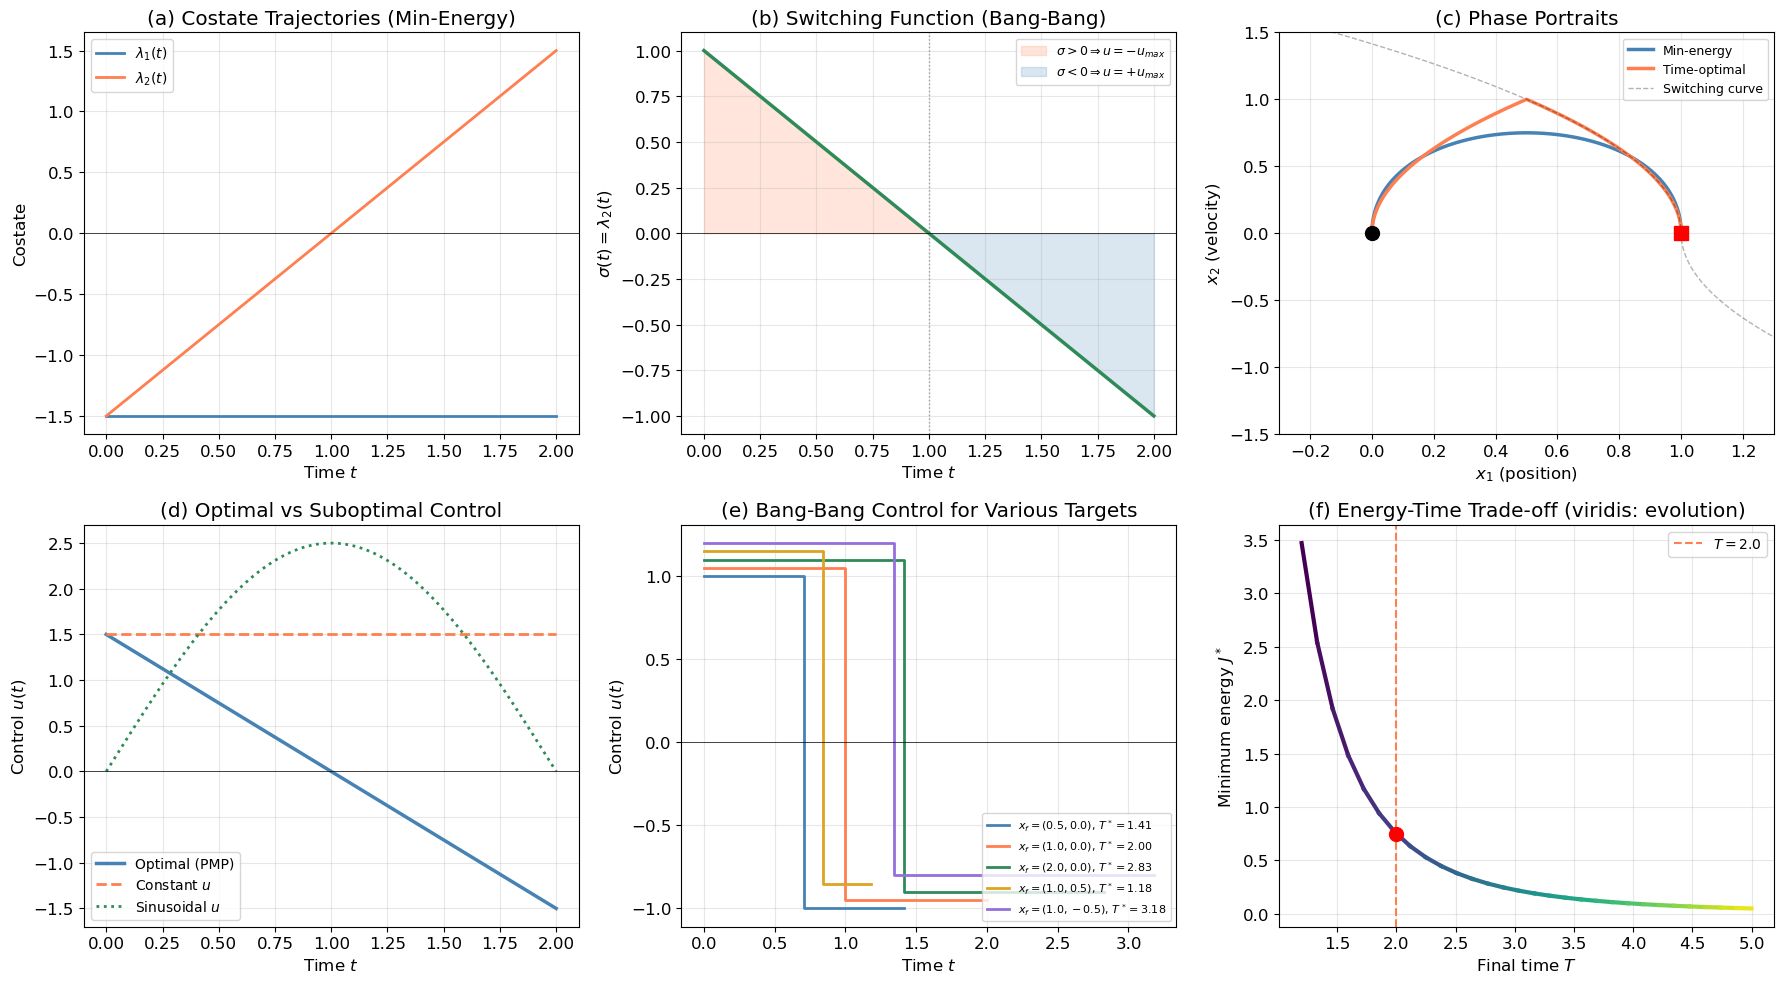

In [17]:
# =============================================================================
# Section 9: Comprehensive Visualizations
# =============================================================================

# ---- 6-Panel Summary Figure ----
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (1) Costate trajectories — minimum energy
ax = axes[0, 0]
ax.plot(t_grid, lam1_an, color='steelblue', linewidth=2, label='$\\lambda_1(t)$')
ax.plot(t_grid, lam2_an, color='coral', linewidth=2, label='$\\lambda_2(t)$')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Time $t$')
ax.set_ylabel('Costate')
ax.set_title('(a) Costate Trajectories (Min-Energy)')
ax.legend(fontsize=10)

# (2) Switching function with sign changes — bang-bang
ax = axes[0, 1]
ax.plot(t_sim, sigma_bb, color='seagreen', linewidth=2.5)
ax.fill_between(t_sim, sigma_bb, 0, where=sigma_bb > 0,
                alpha=0.2, color='coral', label='$\\sigma > 0 \\Rightarrow u = -u_{max}$')
ax.fill_between(t_sim, sigma_bb, 0, where=sigma_bb < 0,
                alpha=0.2, color='steelblue', label='$\\sigma < 0 \\Rightarrow u = +u_{max}$')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(t_sw, color='gray', linewidth=1, linestyle=':', alpha=0.7)
ax.set_xlabel('Time $t$')
ax.set_ylabel('$\\sigma(t) = \\lambda_2(t)$')
ax.set_title('(b) Switching Function (Bang-Bang)')
ax.legend(fontsize=9)

# (3) Phase portraits — both problems
ax = axes[0, 2]
ax.plot(x1_an, x2_an, color='steelblue', linewidth=2.5, label='Min-energy')
ax.plot(x1_bb, x2_bb, color='coral', linewidth=2.5, label='Time-optimal')
ax.plot(0, 0, 'ko', markersize=10, zorder=5)
ax.plot(1, 0, 'rs', markersize=10, zorder=5)
# Switching curve
x2_sw = np.linspace(-2, 2, 300)
x1_sw = -np.sign(x2_sw) * x2_sw**2 / (2 * U_MAX) + XF_BANG[0]
ax.plot(x1_sw, x2_sw, 'k--', alpha=0.3, linewidth=1, label='Switching curve')
ax.set_xlabel('$x_1$ (position)')
ax.set_ylabel('$x_2$ (velocity)')
ax.set_title('(c) Phase Portraits')
ax.legend(fontsize=9)
ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-1.5, 1.5)

# (4) Optimal vs suboptimal control profiles
ax = axes[1, 0]
ax.plot(t_grid, u_an, color='steelblue', linewidth=2.5, label='Optimal (PMP)')
# Suboptimal: constant control
u_const = 6 * (XF_ENERGY[0] - X0_ENERGY[0]) / T_FINAL_ENERGY**2
u_subopt1 = u_const * np.ones_like(t_grid)
ax.plot(t_grid, u_subopt1, color='coral', linewidth=2, linestyle='--', label='Constant $u$')
# Suboptimal: sinusoidal
u_subopt2 = 2.5 * np.sin(np.pi * t_grid / T_FINAL_ENERGY)
ax.plot(t_grid, u_subopt2, color='seagreen', linewidth=2, linestyle=':', label='Sinusoidal $u$')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Time $t$')
ax.set_ylabel('Control $u(t)$')
ax.set_title('(d) Optimal vs Suboptimal Control')
ax.legend(fontsize=10)

# (5) Bang-bang control timeline
ax = axes[1, 1]
# Show multiple bang-bang solutions for different targets
targets = [(0.5, 0.0), (1.0, 0.0), (2.0, 0.0), (1.0, 0.5), (1.0, -0.5)]
colors_bb = ['steelblue', 'coral', 'seagreen', 'goldenrod', 'mediumpurple']
for idx_target, (x1_target, x2_target) in enumerate(targets):
    try:
        xf_t = np.array([x1_target, x2_target])
        ts, tf, ui = bang_bang_double_integrator(X0_BANG, xf_t, U_MAX)
        t_plot = np.array([0, ts - 1e-10, ts + 1e-10, tf])
        u_plot = np.array([ui, ui, -ui, -ui])
        ax.step(t_plot, u_plot + idx_target * 0.05, color=colors_bb[idx_target],
                linewidth=2, where='post',
                label=f'$x_f = ({x1_target}, {x2_target})$, $T^* = {tf:.2f}$')
    except ValueError:
        pass
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Time $t$')
ax.set_ylabel('Control $u(t)$')
ax.set_title('(e) Bang-Bang Control for Various Targets')
ax.legend(fontsize=8, loc='lower right')

# (6) Energy-time trade-off curve (viridis for evolution)
ax = axes[1, 2]
T_values = np.linspace(1.2, 5.0, 30)
J_values = []
for T_val in T_values:
    _, _, u_val, _, _ = analytical_energy_solution(
        np.linspace(0, T_val, 500), T_val, X0_ENERGY, XF_ENERGY
    )
    J_val = 0.5 * np.trapezoid(u_val**2, np.linspace(0, T_val, 500))
    J_values.append(J_val)

colors_et = plt.cm.viridis(np.linspace(0, 1, len(T_values)))
for j_idx in range(len(T_values) - 1):
    ax.plot(T_values[j_idx:j_idx+2], J_values[j_idx:j_idx+2],
            color=colors_et[j_idx], linewidth=3)
ax.axvline(T_FINAL_ENERGY, color='coral', linestyle='--', linewidth=1.5,
           label=f'$T = {T_FINAL_ENERGY}$')
J_at_T = 0.5 * np.trapezoid(u_an**2, t_grid)
ax.plot(T_FINAL_ENERGY, J_at_T, 'ro', markersize=10, zorder=5)
ax.set_xlabel('Final time $T$')
ax.set_ylabel('Minimum energy $J^*$')
ax.set_title('(f) Energy-Time Trade-off (viridis: evolution)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

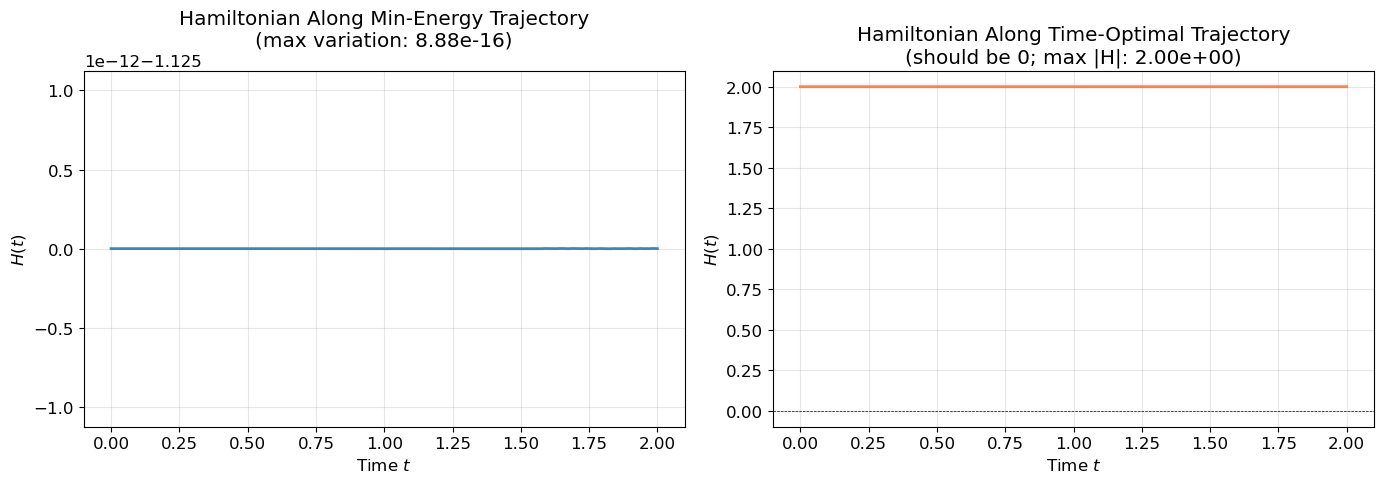

In [18]:
# ---- Hamiltonian evolution along optimal trajectories ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Min-energy Hamiltonian (should be constant)
ax = axes[0]
ax.plot(t_grid, H_energy_traj, color='steelblue', linewidth=2)
ax.set_xlabel('Time $t$')
ax.set_ylabel('$H(t)$')
ax.set_title(f'Hamiltonian Along Min-Energy Trajectory\n(max variation: {H_variation:.2e})')

# Right: Time-optimal Hamiltonian (should be 0 for free-time problem)
ax = axes[1]
H_time_traj = np.zeros_like(t_sim)
for i in range(len(t_sim)):
    x_i = np.array([x1_bb[i], x2_bb[i]])
    lam_i = np.array([lam1_bb[i], lam2_bb[i]])
    H_time_traj[i] = hamiltonian(x_i, lam_i, u_bb[i], t_sim[i], problem='time')

ax.plot(t_sim, H_time_traj, color='coral', linewidth=2)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
H_time_variation = np.max(np.abs(H_time_traj))
ax.set_xlabel('Time $t$')
ax.set_ylabel('$H(t)$')
ax.set_title(f'Hamiltonian Along Time-Optimal Trajectory\n(should be 0; max |H|: {H_time_variation:.2e})')

plt.tight_layout()
plt.show()

In [19]:
# =============================================================================
# Final Summary Verification
# =============================================================================

print("=" * 70)
print("VERIFICATION SUMMARY")
print("=" * 70)

# 1. Costate satisfies adjoint equation
print(f"Costate adjoint equation (RK4): max relative error = {max(err_rk4_x1, err_rk4_lam):.2e} [{status_rk4}]")

# 2. Hamiltonian constant along optimal trajectory
print(f"Hamiltonian constancy (min-energy): max |dH| = {H_variation:.2e} [{status_H_const}]")

# 3. Shooting converges to boundary conditions
print(f"Shooting boundary condition: max relative error = {bc_err:.2e} [{status_bc}]")

# 4. Analytical vs numerical minimum-energy solution
print(f"Analytical vs numerical (shooting): max relative error = {max(err_shoot_x1, err_shoot_x2, err_shoot_u):.2e} [{status_shoot}]")
print(f"Analytical vs numerical (BVP):      max relative error = {max(err_bvp_x1, err_bvp_x2, err_bvp_u):.2e} [{status_bvp}]")

print("=" * 70)

VERIFICATION SUMMARY
Costate adjoint equation (RK4): max relative error = 1.27e-14 [PASS]
Hamiltonian constancy (min-energy): max |dH| = 8.88e-16 [PASS]
Shooting boundary condition: max relative error = 6.66e-16 [PASS]
Analytical vs numerical (shooting): max relative error = 2.22e-15 [PASS]
Analytical vs numerical (BVP):      max relative error = 5.55e-16 [PASS]


---
## 10. Extensions

### State Constraints and Jump Conditions

When the state is constrained (e.g., $x(t) \in \mathcal{X}$), the costate $\lambda(t)$ may have **discontinuities** (jumps) at the times when the constraint becomes active or inactive. At a junction point $t_j$ where a state constraint $g(x(t_j)) = 0$ becomes active:

$$\lambda(t_j^+) = \lambda(t_j^-) + \nu \frac{\partial g}{\partial x}(x(t_j))$$

where $\nu \geq 0$ is a multiplier. This is analogous to impulsive forces in mechanics.

### Direct Methods: Collocation

PMP is an **indirect method** — it converts the optimal control problem into a boundary value problem (BVP). An alternative is **direct methods**, which discretize the problem and solve a large nonlinear program (NLP):

1. **Direct shooting:** Parameterize $u(t)$ on a coarse grid, integrate forward, optimize
2. **Direct collocation:** Discretize both $x(t)$ and $u(t)$, enforce dynamics as constraints
3. **Pseudospectral methods:** Use Chebyshev or Legendre polynomials for spectral accuracy

| Method | Pros | Cons |
|--------|------|------|
| PMP (indirect) | High accuracy, small problem size | Requires analytic derivation, sensitive to initial guess |
| Direct collocation | Robust convergence, handles constraints | Large NLP, lower accuracy |
| Pseudospectral | Spectral accuracy, moderate problem size | Complex implementation |

### Connection to the Hamilton-Jacobi-Bellman Equation

PMP provides **necessary** conditions for optimality. **Sufficient** conditions come from the Hamilton-Jacobi-Bellman (HJB) equation — a PDE for the value function $V(x, t)$:

$$-\frac{\partial V}{\partial t} = \min_{u \in \mathcal{U}} \left[ L(x, u, t) + \frac{\partial V}{\partial x} f(x, u, t) \right]$$

The costate in PMP is related to the gradient of the value function: $\lambda(t) = \frac{\partial V}{\partial x}(x^*(t), t)$. While HJB gives the globally optimal feedback policy, it suffers from the **curse of dimensionality** — the PDE must be solved over the entire state space.

### Differential Games

PMP extends naturally to **two-player zero-sum differential games**, where one player minimizes and the other maximizes the cost:

$$\dot{x} = f(x, u, v, t), \quad J = \int_0^T L(x, u, v, t) \, dt$$

The **minimax** version of PMP (Isaacs' equation) yields:

$$u^* = \arg\min_u H, \quad v^* = \arg\max_v H$$

This is the foundation of **pursuit-evasion** problems in robotics and military applications.

### Key Takeaways

1. **PMP** extends the calculus of variations to handle **control constraints** via the Hamiltonian minimization condition
2. The **Hamiltonian** $H = L + \lambda^T f$ unifies the state dynamics, costate equations, and optimality condition
3. **Bang-bang control** arises when $H$ is linear in $u$ — the switching function determines control switches
4. **Shooting methods** convert the BVP from PMP into a root-finding problem
5. **Singular arcs** require higher-order analysis (Kelley condition) and produce chattering phenomena
6. PMP provides **necessary** conditions; HJB provides **sufficient** conditions but at higher computational cost